In [1]:
import lwa_f 
import numpy as np
from lwa_antpos import mapping
import matplotlib.pyplot as plt

Read antpos from default source


In [2]:
#for snap in range(1, 12):
for snap in [1]:
    f = lwa_f.snap2_fengine.Snap2FengineEtcd('snap%.2d' % snap)
    for adc in [0]:
    #for adc in range(64):
        #f.input.use_noise(SNAP_ADC_INDEX) # Use use_adc() when you're finished 
        #corr = f.corr.get_new_corr(adc, adc) # or different indices for a cross correlation. 
        corr = f.autocorr.get_new_spectra(adc)
        print(corr)
# Optionally call corr.set_acc_len(...) first to set the accumulation length. 
# corr is a 512-element complex-valued spectra. (4096 channels with each 8 chans summed)

2026-05-05 20:40:30,584 - lwa_f.blocks.block:snap01 - WARNING - eth - Couldn't find Ethernet core. Will retry later


[[4.062458174303174e-07, 2.9681324065222725e-10, 2.862618231347369e-08, 1.1102549279939922e-07, 1.1279084333182254e-09, 1.2860990494800717e-08, 5.522089452369983e-10, 6.66853239295051e-10, 2.3410944294255387e-09, 6.471800872986933e-11, 1.077893330148072e-10, 2.1233859115454834e-10, 5.88276094504181e-11, 1.3747225580118538e-10, 5.95310467588206e-11, 5.5356608186230005e-11, 6.660805240699119e-11, 5.508837830348057e-11, 5.7134741382469656e-11, 5.5566218293279235e-11, 5.548095316498802e-11, 5.5354831829390605e-11, 5.589484430856828e-11, 5.508482558980177e-11, 5.567102334680385e-11, 5.4505733260157285e-11, 5.501732402990456e-11, 5.524647406218719e-11, 5.4937387972131546e-11, 5.508660194664117e-11, 5.583622453286807e-11, 5.60422819262385e-11, 5.6127547054529714e-11, 5.5560889222761034e-11, 5.544542602820002e-11, 5.67332847367652e-11, 5.7553961596568115e-11, 5.6992632835317636e-11, 5.866240826435387e-11, 5.852385243088065e-11, 5.841904737735604e-11, 5.999467589390406e-11, 6.014388986841368e-1

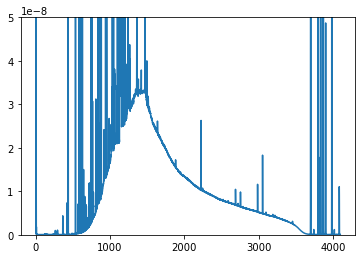

In [8]:
plt.plot(corr[2])
plt.ylim([0, 5e-8])
plt.show()

In [11]:
antname = mapping.snap2_to_antpol("snap01",2)
print(antname)

LWA-259A


In [12]:
f = open(f"/opt/devel/rbyrne/requantization_sim/{antname}_spectrum_09Mar26.npy", "wb")
np.save(f, corr[2])
f.close()

In [ ]:
snap2names = ['snap01', 'snap02', 'snap03', 'snap04', 'snap05', 'snap06', 'snap07', 'snap08', 'snap09', 'snap10', 'snap11']
Nblocks = 4
Nantpols_per_block = 16
spec = []
snap_nums = []
antnames = []
for snap2name in snap2names:
    snap2num = int(snap2name.lstrip('snap'))
    f = lwa_f.snap2_fengine.Snap2Fengine(snap2name)
    for pol_block in range(Nblocks):
        try:
            spec_new = f.autocorr.get_new_spectra(pol_block)
            spec.append(spec_new)
            snap_nums.extend([snap2num]*Nantpols_per_block)
            for ind in range(Nantpols_per_block):
                antnames.append(mapping.snap2_to_antpol(snap2name, pol_block * Nantpols_per_block + ind))
        except:
            print("ERROR")

spec = np.concatenate(spec, axis=0)

2026-03-09 20:58:21,705 - lwa_f.blocks.block:snap01 - INFO - adc - Detected FMC ADC board on port 0
2026-03-09 20:58:22,118 - lwa_f.blocks.block:snap01 - INFO - adc - Detected FMC ADC board on port 1
2026-03-09 20:58:22,119 - lwa_f.blocks.block:snap01 - WARNING - powermon - Error while trying to initialize I2C objects
ERROR
ERROR
ERROR
ERROR
2026-03-09 20:58:23,600 - lwa_f.blocks.block:snap02 - INFO - adc - Detected FMC ADC board on port 0
2026-03-09 20:58:24,033 - lwa_f.blocks.block:snap02 - INFO - adc - Detected FMC ADC board on port 1
2026-03-09 20:58:24,034 - lwa_f.blocks.block:snap02 - WARNING - powermon - Error while trying to initialize I2C objects
ERROR
ERROR
ERROR
ERROR
2026-03-09 20:58:25,947 - lwa_f.blocks.block:snap03 - INFO - adc - Detected FMC ADC board on port 0
2026-03-09 20:58:26,314 - lwa_f.blocks.block:snap03 - INFO - adc - Detected FMC ADC board on port 1
2026-03-09 20:58:26,315 - lwa_f.blocks.block:snap03 - WARNING - powermon - Error while trying to initialize I2C 

ValueError: need at least one array to concatenate

In [11]:
np.shape(spec)

(624, 4096)

In [13]:
np.shape(antnames)

(624,)

In [ ]:
f = open("/lustre/rbyrne/LWA_spectra_Jan29_2pm.npy", "wb")
np.save(f, spec)
np.save(f, antnames)
f.close()

In [ ]:
f = open("/lustre/rbyrne/LWA_spectra_Jan27.npy", "rb")
spec = np.load(f)
antnames = np.load(f)
f.close()

In [20]:
np.shape(spec)

(624, 4096)

In [4]:
mapping.digitizer_to_antpol(3, 63)

AttributeError: module 'lwa_antpos.mapping' has no attribute 'digitizer_to_antpol'

In [9]:
# Implement noise injection
#SNAPNAME = 'snap01' 
#SNAP_ADC_INDEX = 7 # The ADC you want to capture 
for snap in range(1, 12):
    f = lwa_f.snap2_fengine.Snap2FengineEtcd('snap%.2d' % snap)
    for adc in range(64):
        #f.input.use_noise(adc)
        f.input.use_adc(adc)

2025-06-25 23:05:18,684 - lwa_f.blocks.block:snap01 - WARNING - eth - Couldn't find Ethernet core. Will retry later
2025-06-25 23:05:20,460 - lwa_f.blocks.block:snap02 - WARNING - eth - Couldn't find Ethernet core. Will retry later
2025-06-25 23:05:22,134 - lwa_f.blocks.block:snap03 - WARNING - eth - Couldn't find Ethernet core. Will retry later
2025-06-25 23:05:23,924 - lwa_f.blocks.block:snap04 - WARNING - eth - Couldn't find Ethernet core. Will retry later
2025-06-25 23:05:25,624 - lwa_f.blocks.block:snap05 - WARNING - eth - Couldn't find Ethernet core. Will retry later
2025-06-25 23:05:27,608 - lwa_f.blocks.block:snap06 - WARNING - eth - Couldn't find Ethernet core. Will retry later
2025-06-25 23:05:30,976 - lwa_f.blocks.block:snap07 - WARNING - eth - Couldn't find Ethernet core. Will retry later
2025-06-25 23:05:34,299 - lwa_f.blocks.block:snap08 - WARNING - eth - Couldn't find Ethernet core. Will retry later
2025-06-25 23:05:37,747 - lwa_f.blocks.block:snap09 - WARNING - eth - Co

In [7]:
f.input.use_adc(SNAP_ADC_INDEX)

In [7]:
mapping.snap2_to_antpol("snap01", 0)

'LWA-266A'